In [16]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [13]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv", encoding="utf-8-sig")

In [2]:
df.head()

,분할경주여부,마명,마번,기수번호,조교사번호,부담구분,출전번호,경주일자,경주거리,경주등급,...,경주로상태,날씨,마체중,출생일,성별,소유자명,생산국,부마명,소재지,순위점수
0,0,파이널축제,45339,080342,70170.0,2,3,2023-01-07,1300,일반,...,양호,흐림,490.0,2020-03-10,수,럭키,한국,지롤라모,서울경마공원,0.636364
1,0,아르고리치,45921,080366,70146.0,2,6,2023-01-07,1300,일반,...,양호,흐림,496.0,2020-04-08,수,우태율,한국,컬러즈플라잉,서울경마공원,0.909091
2,0,파워에치드,45734,080339,70166.0,2,11,2023-01-07,1300,일반,...,양호,흐림,483.0,2020-03-18,거,박정재,한국,에치드,서울경마공원,0.363636
3,0,베스트선,45369,080405,70115.0,3,1,2023-01-07,1300,일반,...,양호,흐림,479.0,2020-02-28,거,베스트샤인조합,한국,테이크차지인디,서울경마공원,0.818182
4,0,슈어윈,45240,080103,70096.0,3,7,2023-01-07,1300,일반,...,양호,흐림,413.0,2020-02-13,암,지성배,한국,BERNARDINI,서울경마공원,1.000000


In [3]:
df.columns

Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주거리',
       '경주등급', '출전마구분', '경주번호', '야간경마여부', '순위', '마필등급', '경주기록', '출주두수',
       '경주로상태', '날씨', '마체중', '출생일', '성별', '소유자명', '생산국', '부마명', '소재지', '순위점수'],
      dtype='str')

In [9]:
df.dtypes.to_frame("dtype")

,dtype
분할경주여부,int64
마명,str
마번,int64
기수번호,str
조교사번호,float64
부담구분,int64
출전번호,int64
경주일자,str
경주거리,int64
경주등급,str


# 

초기 shape: (15460, 28)
중복 컬럼 제거 후: (15460, 28)
완전 동일 컬럼 제거: []


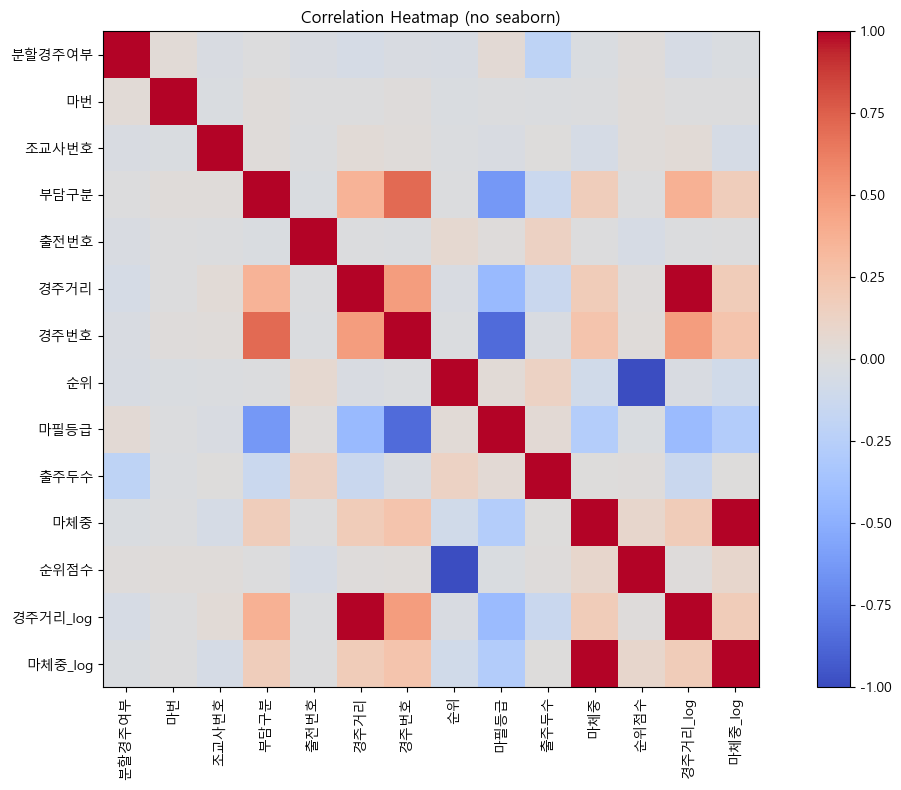

상관 기반 제거 컬럼: ['경주거리_log', '마체중_log']
최종 shape: (15460, 26)

===== 분할경주여부 =====


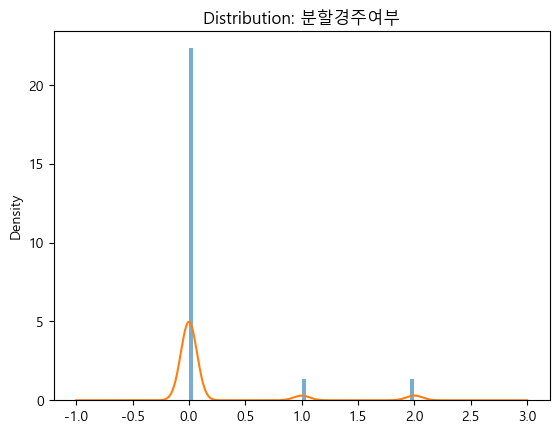

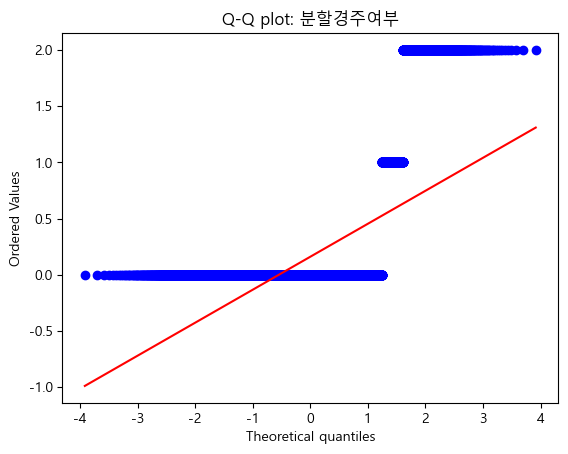

p-value: 6.975945260466431e-73
→ 정규분포 아님

===== 마번 =====


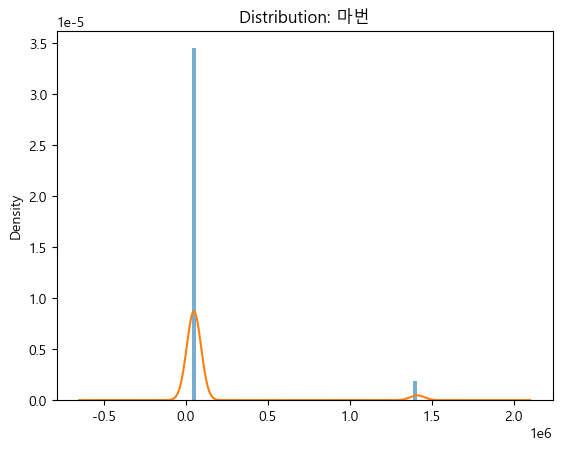

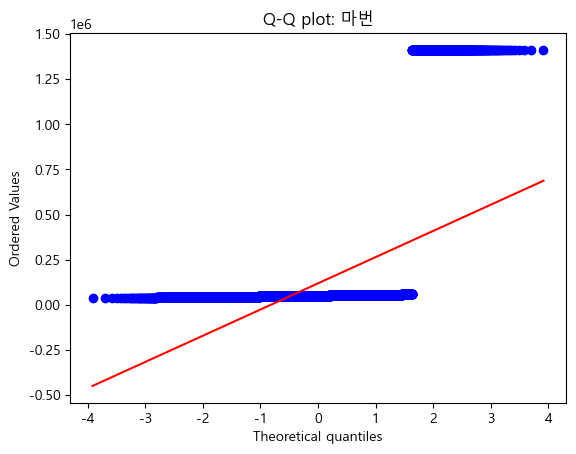

p-value: 4.449782066184826e-77
→ 정규분포 아님

===== 조교사번호 =====


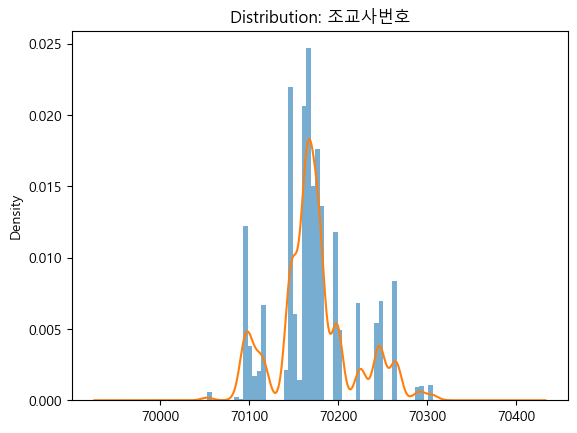

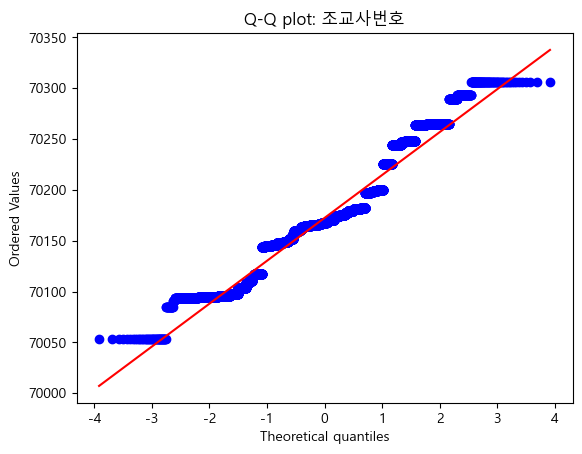

p-value: 2.471880975027127e-33
→ 정규분포 아님

===== 부담구분 =====


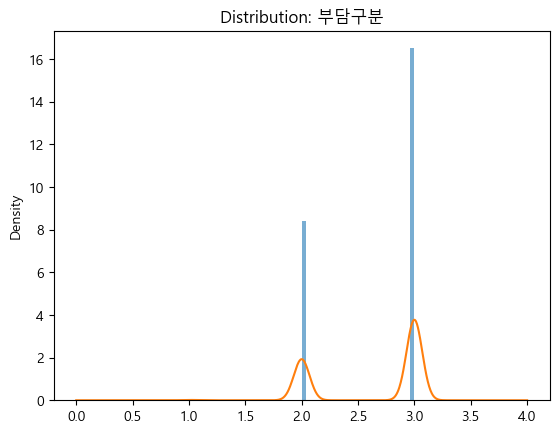

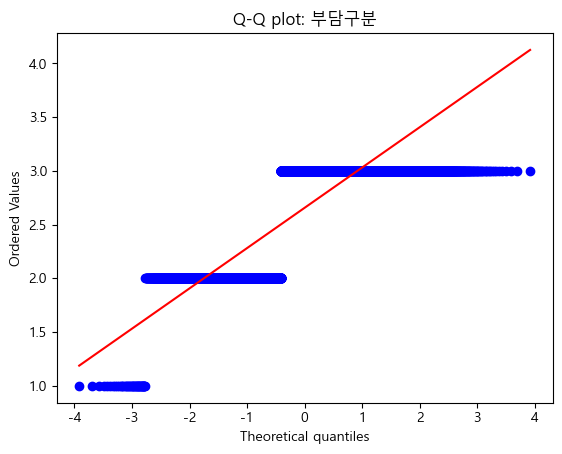

p-value: 2.0019707059134024e-63
→ 정규분포 아님

===== 출전번호 =====


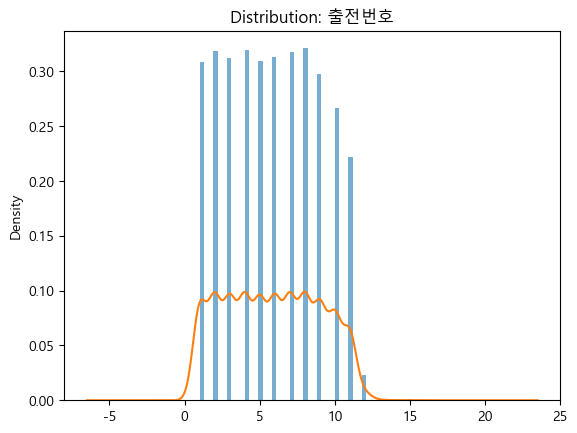

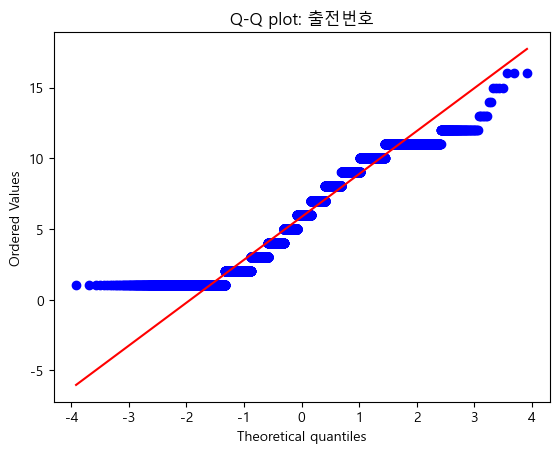

p-value: 1.4660464506040015e-31
→ 정규분포 아님

===== 경주거리 =====


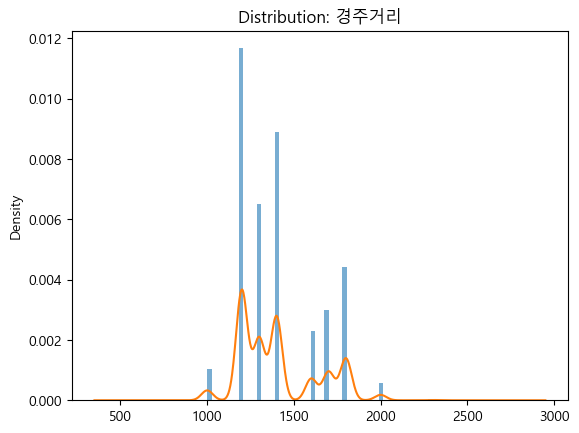

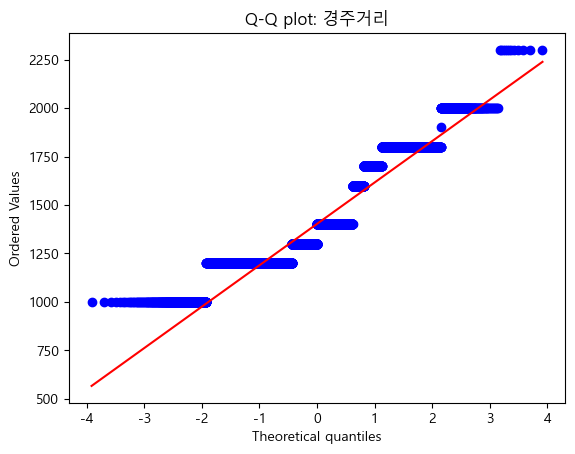

p-value: 3.0130907410379443e-43
→ 정규분포 아님

===== 경주번호 =====


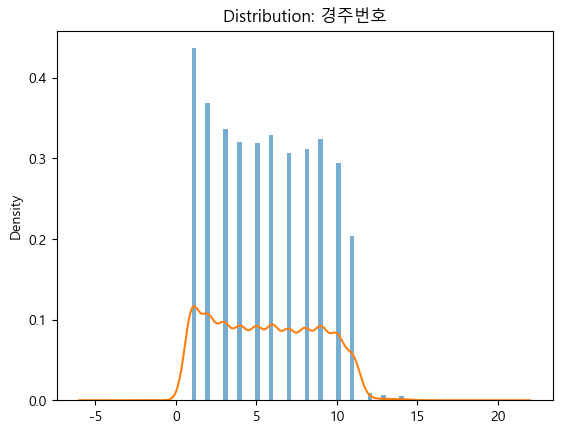

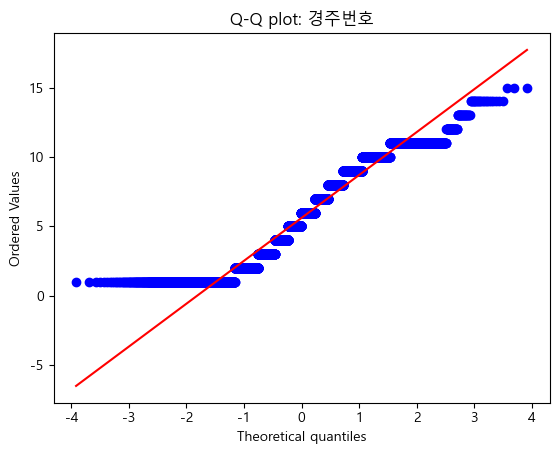

p-value: 5.6490095350203835e-33
→ 정규분포 아님

===== 순위 =====


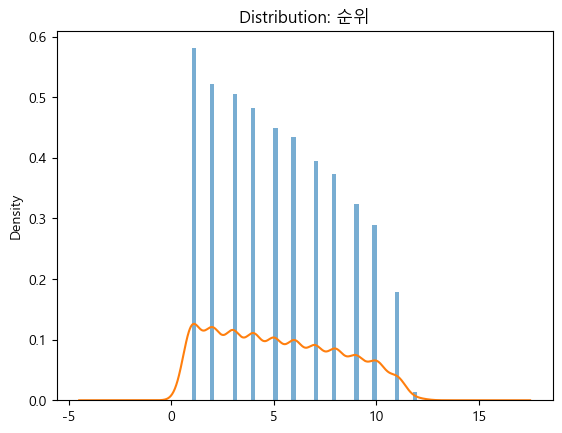

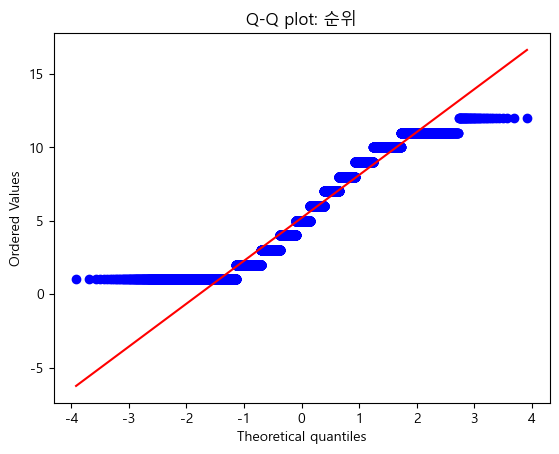

p-value: 2.7237619069438194e-33
→ 정규분포 아님

===== 마필등급 =====


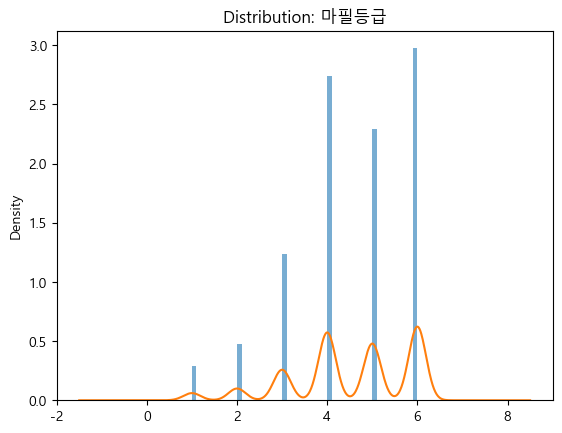

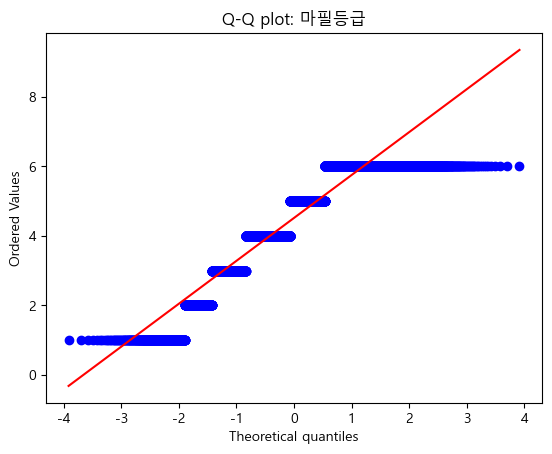

p-value: 7.55585643161447e-43
→ 정규분포 아님

===== 출주두수 =====


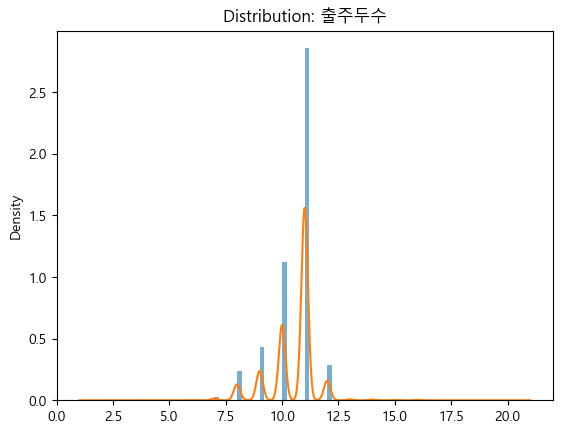

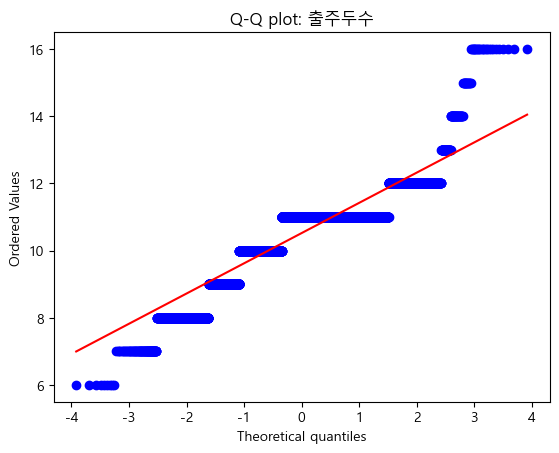

p-value: 4.774891754581643e-51
→ 정규분포 아님

===== 마체중 =====


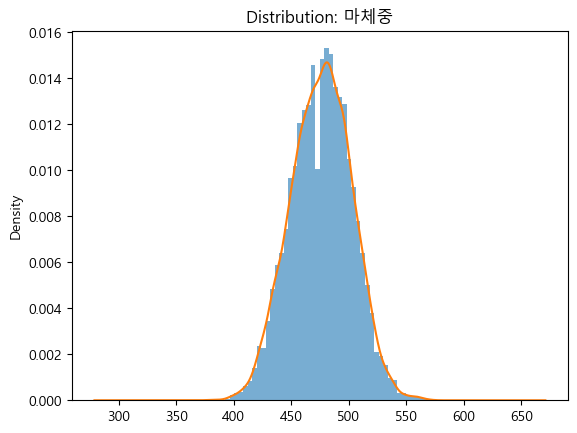

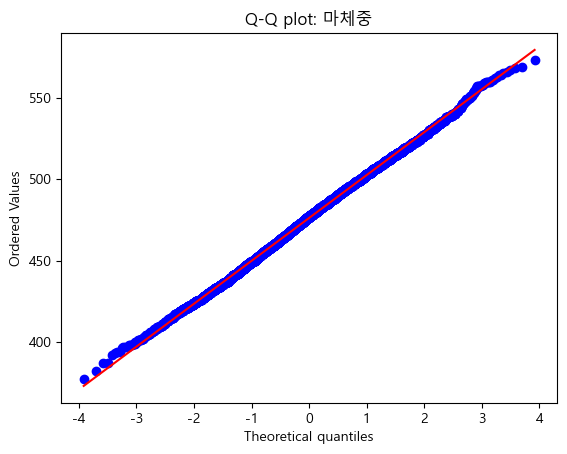

p-value: 0.10341369709000037
→ 정규분포 가능성 있음

===== 순위점수 =====


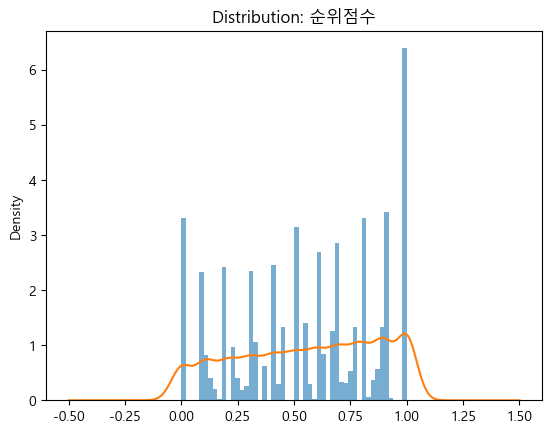

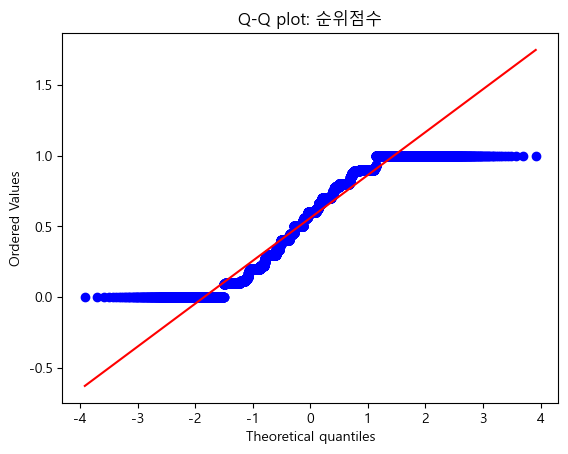

p-value: 1.5172633389376028e-33
→ 정규분포 아님
전처리 완료


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================
# 0. 데이터 로드
# =========================

print("초기 shape:", df.shape)


# =========================
# 1. 완전 중복 컬럼 제거
# =========================
df = df.loc[:, ~df.T.duplicated()]
print("중복 컬럼 제거 후:", df.shape)


# =========================
# 2. 완전 동일 값 컬럼 제거
# =========================
duplicate_cols = []

cols = df.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            duplicate_cols.append(cols[j])

df = df.drop(columns=set(duplicate_cols))
print("완전 동일 컬럼 제거:", duplicate_cols)


# =========================
# 3. 숫자형 컬럼
# =========================
num_df = df.select_dtypes(include=["int64", "float64"])


# =========================
# 4. 상관도 (matplotlib 버전)
# =========================
corr = num_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (no seaborn)")
plt.tight_layout()
plt.show()


# =========================
# 5. 상관 기반 feature 제거
# =========================
threshold = 0.9

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df = df.drop(columns=to_drop)

print("상관 기반 제거 컬럼:", to_drop)
print("최종 shape:", df.shape)


# =========================
# 6. 정규성 체크 함수 (matplotlib only)
# =========================
def check_normality(data, col, sample_size=3000):
    print(f"\n===== {col} =====")

    values = data[col].dropna()

    # 히스토그램 (seaborn 대신 matplotlib)
    plt.figure()
    plt.hist(values, bins=50, density=True, alpha=0.6)

    # KDE (간단 근사)
    values.plot(kind="kde")

    plt.title(f"Distribution: {col}")
    plt.show()

    # Q-Q plot
    plt.figure()
    stats.probplot(values, dist="norm", plot=plt)
    plt.title(f"Q-Q plot: {col}")
    plt.show()

    # Shapiro test
    sample = values
    if len(sample) > sample_size:
        sample = sample.sample(sample_size)

    stat, p = stats.shapiro(sample)

    print("p-value:", p)

    if p > 0.05:
        print("→ 정규분포 가능성 있음")
    else:
        print("→ 정규분포 아님")


# =========================
# 7. numeric 전체 검사
# =========================
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    check_normality(df, col)


# =========================
# 8. 로그 변환
# =========================
if "경주거리" in df.columns:
    df["경주거리_log"] = np.log1p(df["경주거리"])

if "마체중" in df.columns:
    df["마체중_log"] = np.log1p(df["마체중"])

print("전처리 완료")

In [19]:


df.head()

,분할경주여부,마명,마번,기수번호,조교사번호,부담구분,출전번호,경주일자,경주거리,경주등급,...,마체중,출생일,성별,소유자명,생산국,부마명,소재지,순위점수,경주거리_log,마체중_log
0,0,파이널축제,45339,080342,70170.0,2,3,2023-01-07,1300,일반,...,490.0,2020-03-10,수,럭키,한국,지롤라모,서울경마공원,0.636364,7.170888,6.196444
1,0,아르고리치,45921,080366,70146.0,2,6,2023-01-07,1300,일반,...,496.0,2020-04-08,수,우태율,한국,컬러즈플라잉,서울경마공원,0.909091,7.170888,6.208590
2,0,파워에치드,45734,080339,70166.0,2,11,2023-01-07,1300,일반,...,483.0,2020-03-18,거,박정재,한국,에치드,서울경마공원,0.363636,7.170888,6.182085
3,0,베스트선,45369,080405,70115.0,3,1,2023-01-07,1300,일반,...,479.0,2020-02-28,거,베스트샤인조합,한국,테이크차지인디,서울경마공원,0.818182,7.170888,6.173786
4,0,슈어윈,45240,080103,70096.0,3,7,2023-01-07,1300,일반,...,413.0,2020-02-13,암,지성배,한국,BERNARDINI,서울경마공원,1.000000,7.170888,6.025866
